# Netflix Content Strategy & Platform Performance Analysis

Prepared by: Usama Saeed Tanoli

*LinkedIn:* https://pk.linkedin.com/in/usama-saeed-tanoli-476383256 <br>
*GitHub:* https://github.com/usamasaeedprojects/netflix-content-strategy-analysis#<br>
*Medium:* https://medium.com/@usama.saeed.tanoli.work/netflix-content-strategy-platform-performance-analysis-99e114c7e46e?postPublishedType=initial

---


## Executive Summary

This report analyzes Netflix's content catalog to understand trends in content growth, format preferences, geographic distribution, and strategic shifts over time. The analysis is purely exploratory and focuses on descriptive insights derived from the dataset.

**Key insights include:**
- Rapid acceleration of content additions after 2016
- Increasing dominance of TV Shows as a retention-focused strategy
- Strong concentration of content in a small number of countries
- Broad but uneven genre diversification


## Business Context

Netflix operates in a highly competitive and rapidly evolving streaming market where **content strategy is a primary driver of subscriber acquisition, engagement, and retention**. Decisions related to content volume, format (Movies vs. TV Shows), genre mix, and geographic distribution directly influence platform differentiation and long-term growth.

As Netflix has expanded globally, its content catalog has shifted from a predominantly licensed library to a more diversified mix that includes original productions and region-specific titles. Understanding how the catalog has evolved over time provides insight into **strategic priorities**, such as scaling content supply, emphasizing episodic formats, and investing selectively across markets.

This analysis examines Netflix’s publicly available content catalog to identify **structural patterns and strategic signals** embedded in historical data. The focus is on descriptive insights that reveal how Netflix’s content portfolio has been shaped, rather than on predicting future performance or measuring user engagement.

### Out of scope for this analysis:

* Viewership, watch-time, or subscriber behavior
* Content costs, revenue, or return on investment
* Predictive or forecasting models

The goal is to translate catalog-level data into **business-relevant insights** that reflect Netflix’s content strategy decisions at scale.

## Dataset Overview & Preparation

- Source: Public Netflix titles dataset
- Content types: Movies and TV Shows
- Key features: release year, country, genre, rating, duration

Cleaning steps included handling missing values, normalizing categorical fields, and transforming date-related attributes for analysis.

## Appendix: Detailed Analysis & Visuals

The following section contains the detailed exploratory analysis and visualizations.

## Load and Clean Data

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",

    # grid styling
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,

    "axes.prop_cycle": plt.cycler(
        color=["#E50914", "#B3B3B3"]
    ),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})


### 2. Load Data

Load data into CSV

In [2]:
df = pd.read_csv('../data/raw_data/netflix_titles.csv')

# Drop columns we don't need
df = df.drop(columns=['show_id', 'director'], errors='coerce')


### 3. Clean Date

In [3]:
# If a value cannot be converted to a datetime, instead of raising an error, just set it to NaT (Not a Time, pandas’ version of missing datetime).
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


## 4. Handle duration

In [4]:
# Initialise numeric columns
df['duration_min'] = None
df['duration_seasons'] = None


In [5]:
# Movies -> duration_min
mask_movie = df['type'] == 'Movie'
df.loc[mask_movie, 'duration_min'] = pd.to_numeric(
    df.loc[mask_movie, 'duration'].str.extract(r'(\d+)')[0],
    errors = 'coerce'
)


In [6]:
# TV Shows -> duration_seasons
mask_tv = df['type'] == 'TV Show'
df.loc[mask_tv, 'duration_seasons'] = pd.to_numeric(
    df.loc[mask_tv, 'duration'].str.extract(r'(\d+)')[0],
    errors = 'coerce'
)


## 5. Fill Missing Values

### Numeric

In [7]:
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
df['duration_min'] = df['duration_min'].fillna(df['duration_min'].median())

df['duration_seasons'] = pd.to_numeric(df['duration_seasons'], errors='coerce')
df['duration_seasons'] = df['duration_seasons'].fillna(df['duration_seasons'].median())


### Categorical

In [8]:
# Categorical -> fill 'Unknown'
cats_cols = ['type', 'rating', 'country', 'listed_in']
for col in cats_cols:
    df[col] = df[col].fillna('Unknown')


### Text

In [9]:
# Text -> fill 'Unknown'
text_cols = ['title', 'cast', 'description']
for col in text_cols:
    df[col] = df[col].fillna('Unknown')


## 6. Set Proper Data Types

In [10]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')
df['country'] = df['country'].astype('category')
df['listed_in'] = df['listed_in'].astype('category')
df['release_year'] = df['release_year'].astype(int)


## 7. Keep Consistent Columns

In [11]:
final_cols = ['type', 'title', 'cast', 'country', 'date_added', 'release_year', 'rating', 
              'duration_min', 'duration_seasons', 'listed_in', 'description']

df = df[final_cols]


## 8. Create Exploded Versions

### 8.1. Country Exploded

In [12]:
df_country = df.copy()
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')
df_country['country'] = df_country['country'].str.strip()


### 8.2. Genre Exploded

In [13]:
df_genre = df.copy()
df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()


### Ensure Columns Match "final_cols"

In [14]:
df_country = df_country[final_cols]
df_genre = df_genre[final_cols]


## 9. Export CSVs

In [15]:
df.to_csv('../data/cleaned_data/cleaned_original.csv', index=False)
df_country.to_csv('../data/cleaned_data/cleaned_by_country.csv', index=False)
df_genre.to_csv('../data/cleaned_data/cleaned_by_genre.csv', index=False)

print('All CSVs exported successfully')

All CSVs exported successfully


## Catalog Composition & Content Characteristics

In [16]:
# Prepare time-based dataset
df_time = df.dropna(subset=['date_added']).copy()
df_time['year_added'] = df_time['date_added'].dt.year
df_time['content_age'] = df_time['year_added'] - df_time['release_year']


### Netflix Accelerates Content Expansion Post-2016

**Context**<br>
Since 2016, Netflix has significantly ramped up content additions, reflecting an aggressive growth strategy.

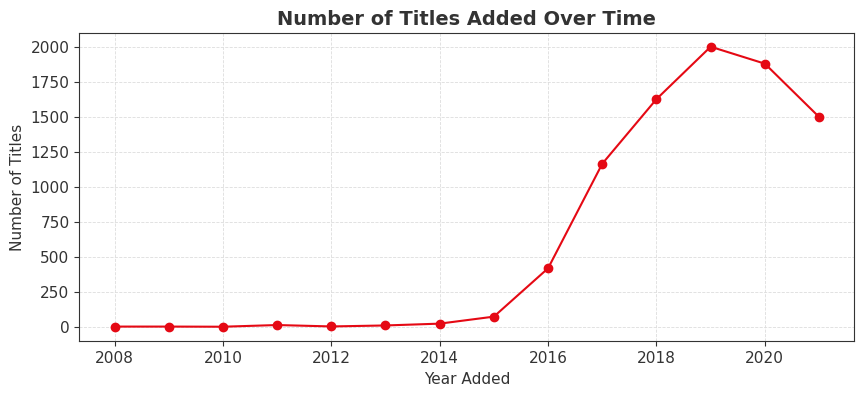

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
dtype: int64

In [17]:
content_by_year = df_time.groupby('year_added').size()

plt.figure(figsize=(10,4))
content_by_year.plot(kind='line', marker='o')
plt.title('Number of Titles Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.savefig('../reports/figures/number_of_titles_added_over_time.png', dpi=300, bbox_inches='tight')

plt.show()

content_by_year

**Insight**<br>
The surge in content highlights Netflix’s focus on broadening its library to appeal to diverse audiences and strengthen market dominance.

**Business Implication**<br>
A rapidly expanding catalog drives subscriber growth, enhances retention, and reinforces Netflix’s competitive edge in the global streaming landscape.

### Netflix Prioritizes Fresh Content

**Context**<br>
Analysis shows that most titles are added within a few years of their original release, rather than older back-catalog content.

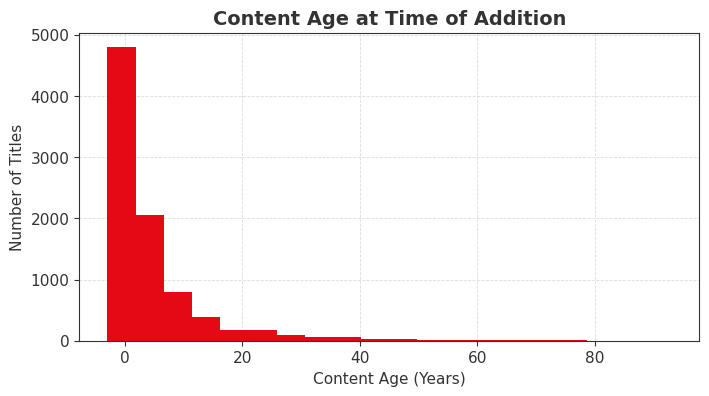

In [18]:
plt.figure(figsize=(8,4))
plt.hist(df_time['content_age'], bins=20)
plt.title('Content Age at Time of Addition')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')

plt.savefig('../reports/figures/content_age_at_time_of_addition.png', dpi=300, bbox_inches='tight')

plt.show()

**Insight**<br>
Netflix favors recently released titles, emphasizing contemporary content that aligns with current audience demand and trends.

**Business Implication**<br>
Focusing on fresh content boosts subscriber engagement, enhances perceived platform relevance, and strengthens competitive positioning against services with older libraries.

### Netflix Focuses on Globally Appealing Genres

**Context**<br>
The platform’s library is dominated by International Movies, Dramas, Comedians, and International TV Shows.

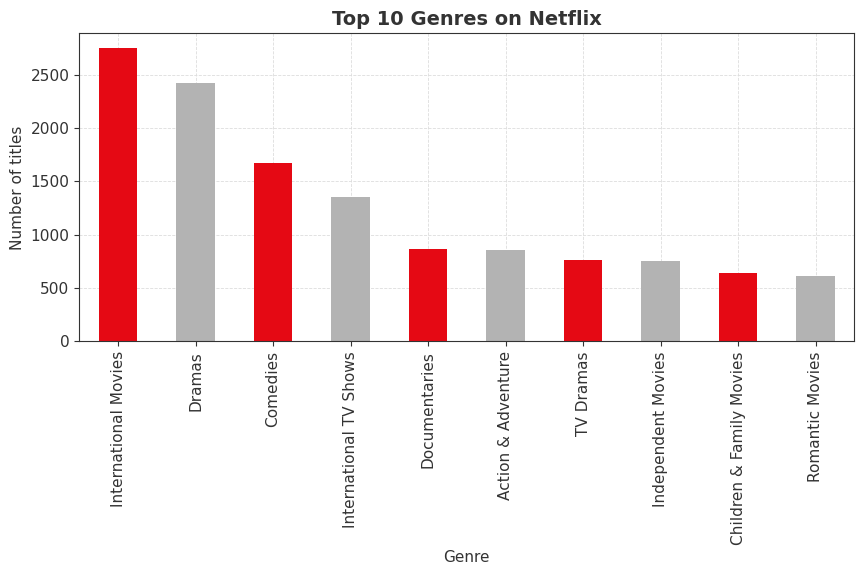

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [19]:
genres = ( df['listed_in'].str.split(', ').explode() )

top_genres = genres.value_counts().head(10) 

plt.figure(figsize=(10,4)) 
top_genres.plot(
    kind = 'bar',
    color = ['#E50914', '#B3B3B3'] * 5
) 
plt.title('Top 10 Genres on Netflix') 
plt.xlabel('Genre') 
plt.ylabel('Number of titles') 

plt.savefig('../reports/figures/top_10_genres_netflix.png', dpi=300, bbox_inches='tight')

plt.show() 

top_genres

**Insight**<br>
Netflix strategically emphasizes genres with broad, cross-border appeal, maximizing content resonance across diverse markets.

**Business Implication**<br>
Prioritizing globally adaptable genres drives international subscriber growth, enhances engagement across regions, and supports Netflix’s global expansion strategy.

### Distinct Investment Strategies for Movies vs. TV Shows

**Context**<br>
Movies dominate across most genres, whereas TV Shows are concentrated in a limited set of categories.

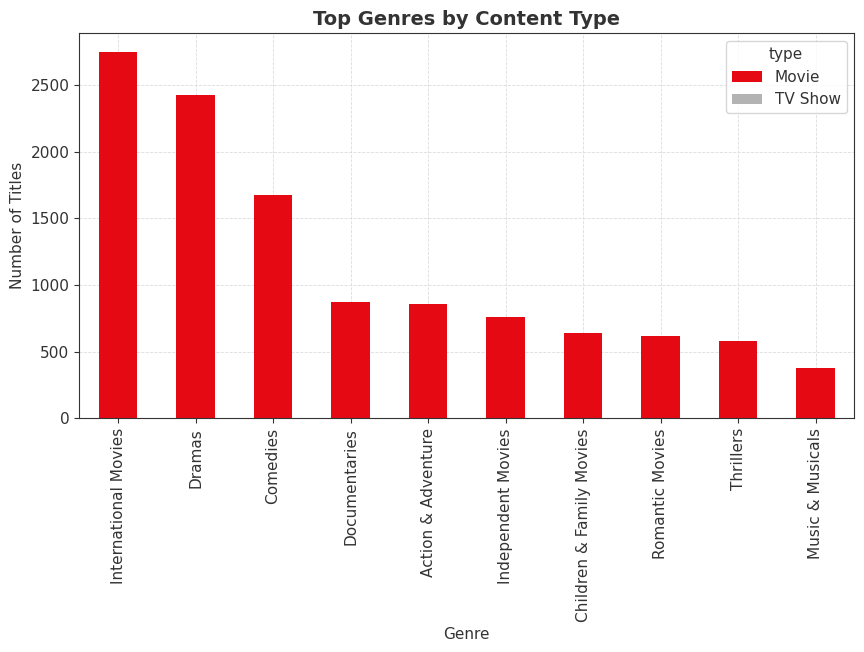

type,Movie,TV Show
genre,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
Documentaries,869,0
Action & Adventure,859,0
Independent Movies,756,0
Children & Family Movies,641,0
Romantic Movies,616,0
Thrillers,577,0


In [20]:
genre_type = (
    df.assign(genre=df['listed_in'].str.split(', '))
    .explode('genre')
    .groupby(['genre', 'type'], observed=False)  # <- added this
    .size()
    .unstack()
    .fillna(0)
    .sort_values(by='Movie', ascending=False)
    .head(10)
)

genre_type.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Top Genres by Content Type')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.savefig('../reports/figures/top_genre_by_content_type.png', dpi=300, bbox_inches='tight')

plt.show()

genre_type


**Insight**<br>
Netflix appears to invest broadly in movies for wide appeal, while targeting TV Shows strategically in select genres to optimize engagement and production ROI.

**Business Implication**<br>
This differentiated approach allows Netflix to balance broad audience reach through movies with focused, high-impact TV Show offerings, enhancing content efficiency and subscriber retention.

### Netflix Content Skews Toward Key Markets

**Context**<br>
The US (3,689), India (1,046), and the UK (804) are the top content contributors, while 831 titles are categorized as Other/Unknown.

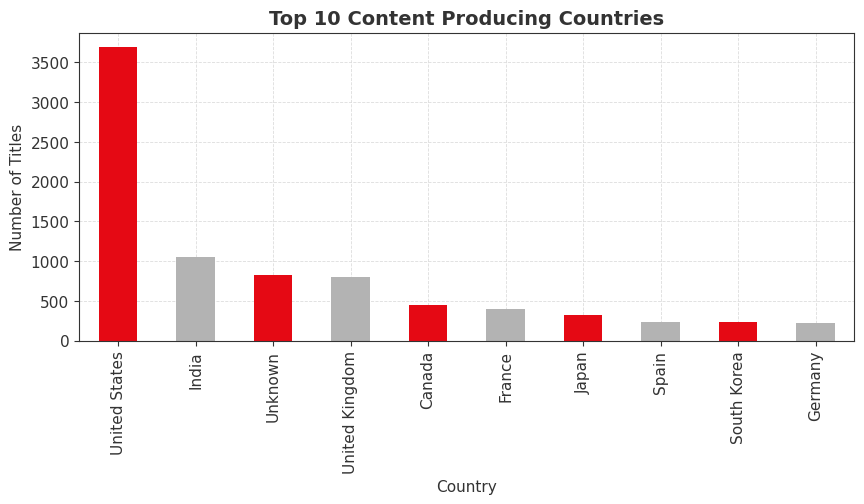

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [21]:
countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
)

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,4))
top_countries.plot(
    kind='bar',
    color = ['#E50914', '#B3B3B3'] * 5

)
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.savefig('../reports/figures/top_10_content_producing_countries.png', dpi=300, bbox_inches='tight')

plt.show()

top_countries

**Insight**<br>
Netflix heavily invests in English-speaking and high-population markets, while a significant portion of content lacks country metadata, highlighting potential gaps in content attribution.

**Business Implication**<br>
Focusing on major markets supports subscriber growth efficiently, but clarifying or leveraging the Unknown segment could reveal untapped content opportunities or strategic market adjustments.

### Netflix Movies Align with Standard Runtime Norms

**Context**<br>
Most Netflix movies have runtimes between 80–120 minutes, consistent with typical feature-length films.

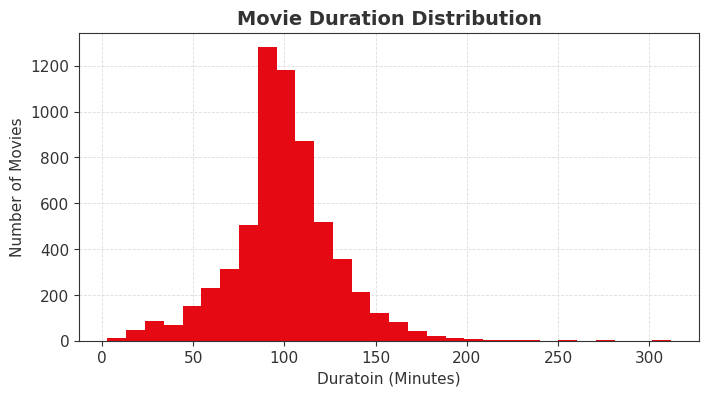

0        90.0
6        91.0
7       125.0
9       104.0
12      127.0
        ...  
8801     96.0
8802    158.0
8804     88.0
8805     88.0
8806    111.0
Name: duration_min, Length: 6131, dtype: float64

In [22]:
movies = df[df['type'] == 'Movie'].copy()
# movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(8,4))
plt.hist(movies['duration_min'], bins=30)
plt.title('Movie Duration Distribution')
plt.xlabel('Duratoin (Minutes)')
plt.ylabel('Number of Movies')

plt.savefig('../reports/figures/movie_duration_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

movies['duration_min']

**Insight**<br>
Netflix curates movie lengths to match standard audience attention spans, balancing engagement with content consumption patterns.

**Business Implication**<br>
Optimizing runtimes enhances viewer satisfaction and completion rates, supporting stronger engagement metrics and reducing churn.

## Platform Strategy & Performance Analysis

### Netflix Maintains a Movie-Heavy Catalog

**Context**<br>
Movies dominate the overall catalog, with TV Shows representing a smaller yet strategic portion.

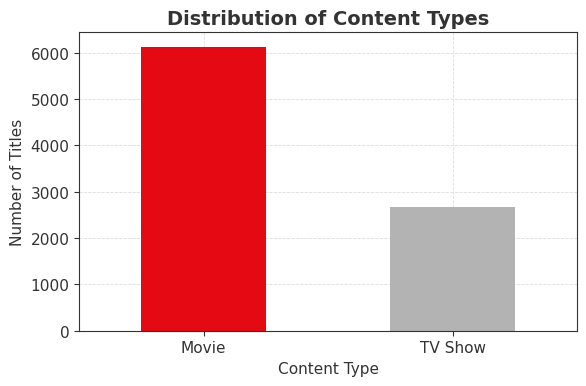

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [23]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(
    kind='bar',
    color = ['#E50914', '#B3B3B3']
)
plt.title('Distribution of Content Types')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('../reports/figures/distribution_of_content_types.png', dpi=300, bbox_inches='tight')

plt.show()

type_counts

**Insight**<br>
Netflix emphasizes a broad movie library to offer variety, while TV Shows serve as a driver for sustained engagement and subscriber retention.

**Business Implication**<br>
A movie-heavy catalog attracts diverse audiences, while selective TV Show investments strengthen loyalty and reduce churn, balancing acquisition and retention strategies.

### Netflix Catalog Concentrated Around Mainstream Ratings

**Context**<br>
The majority of content falls under TV-MA, TV-14, TV-PG, and R ratings, with fewer titles in other categories.

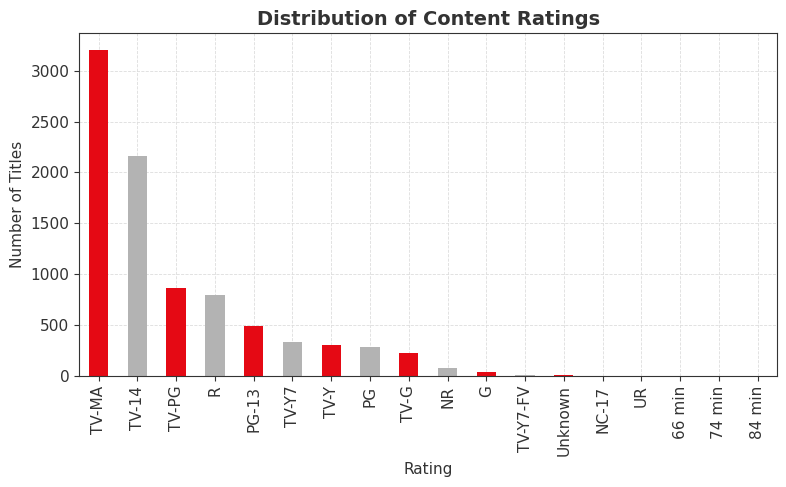

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64

In [24]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(8,5))
rating_counts.plot(
    kind='bar',
    color = ['#E50914', '#B3B3B3'] * 9
    
)
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.tight_layout()

plt.savefig('../reports/figures/distribution_of_content_ratings.png', dpi=300, bbox_inches='tight')

plt.show()

rating_counts

**Insight**<br>
Netflix targets mainstream audiences while selectively offering niche-rated content for specific demographic segments.

**Business Implication**<br>
Focusing on broadly appealing ratings maximizes potential viewership, while niche categories allow targeted engagement, supporting both scale and audience diversification.

### TV Shows Gaining Momentum in Netflix’s Catalog

**Context**<br>
Movies still constitute the majority of content, but TV Shows have grown at a faster rate in recent years.

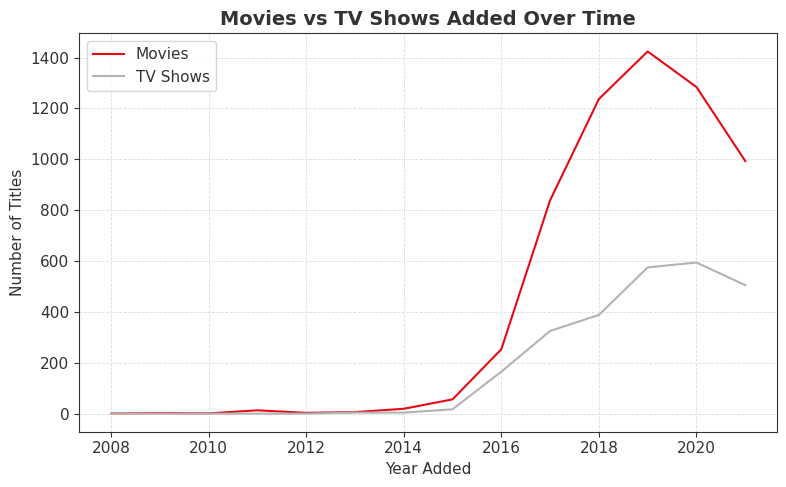

type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,4
2014,19,4
2015,56,17
2016,253,165


In [25]:
type_by_year = df_time.groupby(['year_added', 'type'], observed=False).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
plt.plot(type_by_year.index, type_by_year['Movie'], label='Movies')
plt.plot(type_by_year.index, type_by_year['TV Show'], label='TV Shows')
plt.title('Movies vs TV Shows Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()

plt.savefig('../reports/figures/movies_vs_tv_shows_added_over_time.png', dpi=300, bbox_inches='tight')

plt.show()

type_by_year

**Insight**<br>
Netflix is strategically emphasizing serialized content to drive sustained viewer engagement and deepen platform loyalty.

**Business Implication**<br>
Expanding TV Show offerings supports retention, binge-watching behavior, and long-term subscriber value, complementing the broad reach of a movie-heavy library.

### Netflix Balances Fresh and Legacy Content

**Context**<br>
Most titles are added within a few years of release, though older titles remain in the catalog.

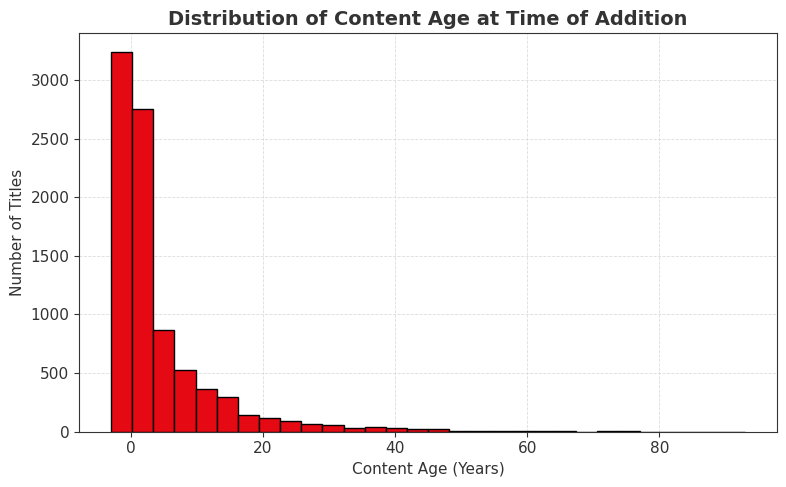

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age, dtype: float64

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df_time['content_age'], bins=30, edgecolor='black')
plt.title('Distribution of Content Age at Time of Addition')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.tight_layout()

plt.savefig('../reports/figures/distribution_of_content_age_at_time_of_addition.png', dpi=300, bbox_inches='tight')

plt.show()

df_time['content_age'].describe()

**Insight**<br>
Netflix prioritizes recent content to stay relevant, while maintaining a long tail of older titles to enhance catalog depth and variety.

**Business Implication**<br>
This approach attracts audiences seeking new releases while satisfying viewers interested in classics, supporting both acquisition and retention strategies.

## Content Diagnostics and Market Comparisons

### Netflix Prioritizes Freshness for TV Shows

**Context**<br>
Average content age on the platform shows TV Shows are added roughly 2.2 years after release, compared to 5.7 years for Movies.

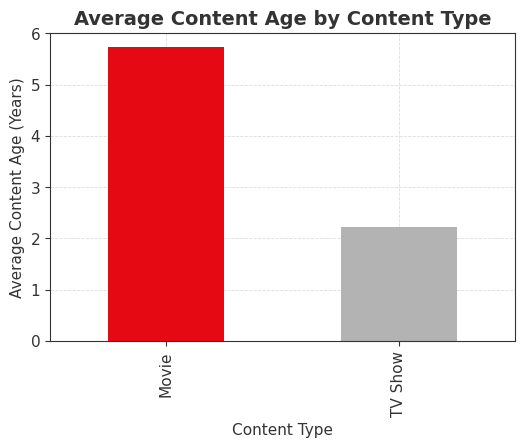

type
Movie      5.727777
TV Show    2.224981
Name: content_age, dtype: float64

In [27]:
content_age_by_type = (
    df_time.groupby('type', observed=False)['content_age']
    .mean()
)

content_age_by_type.plot(
    kind = 'bar',
    color = ['#E50914', '#B3B3B3'],    
    figsize = (6,4),
    title = 'Average Content Age by Content Type'
)

plt.xlabel('Content Type')
plt.ylabel('Average Content Age (Years)')

plt.savefig('../reports/figures/average_content_age_by_content_type.png', dpi=300, bbox_inches='tight')

plt.show()

content_age_by_type

**Insight**<br>
Netflix strongly prioritizes recent TV Shows over Movies, reinforcing a strategy to keep episodic content timely and engaging for subscribers.

**Business Implication**<br>
Faster availability of TV Shows encourages binge-watching and sustained engagement, enhancing retention and platform loyalty.

### Netflix Expands International Movies and TV Dramas

**Context**<br>
International Movies and TV Dramas have shown consistent year-over-year growth in additions.

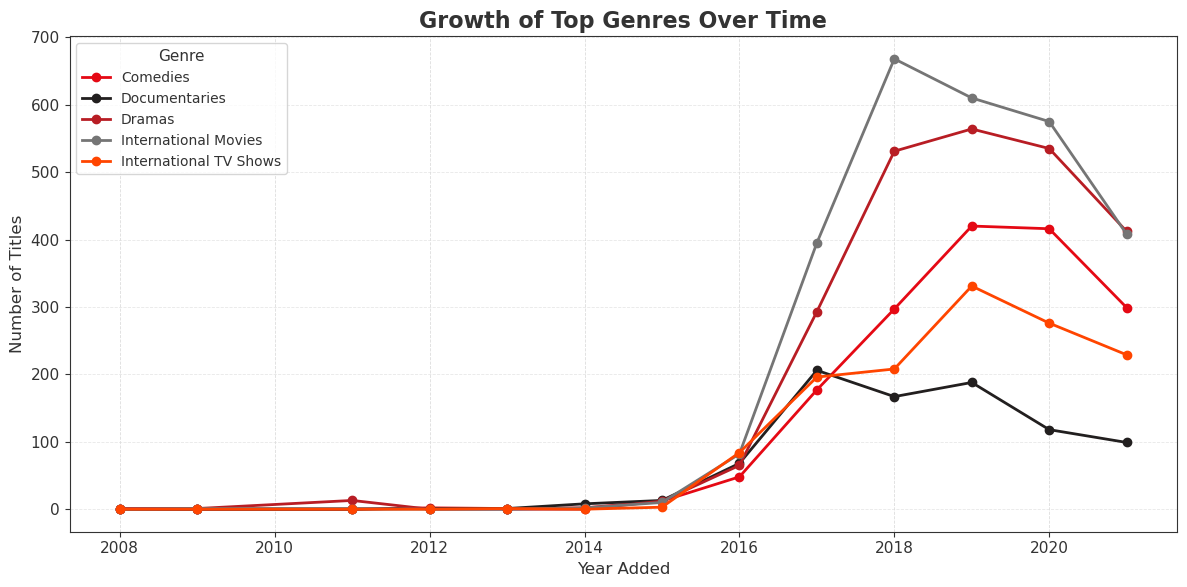

genre,Comedies,Documentaries,Dramas,International Movies,International TV Shows
year_added,,,,,
2008,0.0,0.0,1.0,0.0,0.0
2009,0.0,0.0,1.0,1.0,0.0
2011,0.0,0.0,13.0,1.0,0.0
2012,2.0,1.0,0.0,0.0,0.0
2013,1.0,1.0,0.0,0.0,1.0
2014,2.0,8.0,0.0,2.0,0.0
2015,12.0,13.0,12.0,10.0,3.0
2016,48.0,68.0,65.0,82.0,84.0
2017,177.0,206.0,293.0,395.0,196.0


In [28]:
genre_year = (
    df_time.assign(genre=df_time['listed_in'].str.split(', '))
        .explode('genre')
        .groupby(['year_added', 'genre'])
        .size()
        .reset_index(name='count')
)

top_genre = (
    genre_year.groupby('genre')['count']
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index
)

pivot = (
    genre_year[genre_year['genre'].isin(top_genre)]
        .pivot(index='year_added', columns='genre', values='count').fillna(0)
)

colors = ['#E50914',  # Netflix Red
          '#221F1F',  # Dark Gray / Black
          '#B81D24',  # Dark Red
          '#757575',  # Medium Gray
          '#FF4500']  # White / Light Gray for contrast


# Plotting with five distinct colors
pivot.plot(figsize=(12,6), color=colors, linewidth=2, marker='o')

plt.title('Growth of Top Genres Over Time', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Genre', fontsize=10)
plt.tight_layout()

plt.savefig('../reports/figures/growth_of_top_genres_over_time.png', dpi=300, bbox_inches='tight')

plt.show()

pivot

**Insight**<br>
Netflix is strategically focusing on globally appealing films and serialized dramas to attract diverse audiences and expand international reach.

**Business Implication**<br>
Investing in international and serialized content drives global subscriber growth, strengthens engagement across markets, and supports long-term platform scalability.

### Netflix Adds Reality & Documentary Content Quickly

**Context**<br>
Average content age shows Reality TV (≈1.47 years) and Docuseries (≈1.59 years) are added close to release, while genres like Stand-Up Comedy (≈0.56 years), TV Dramas (≈1.58 years), and Spanish-Language TV Shows (≈1.70 years) rely more on older or staggered additions.

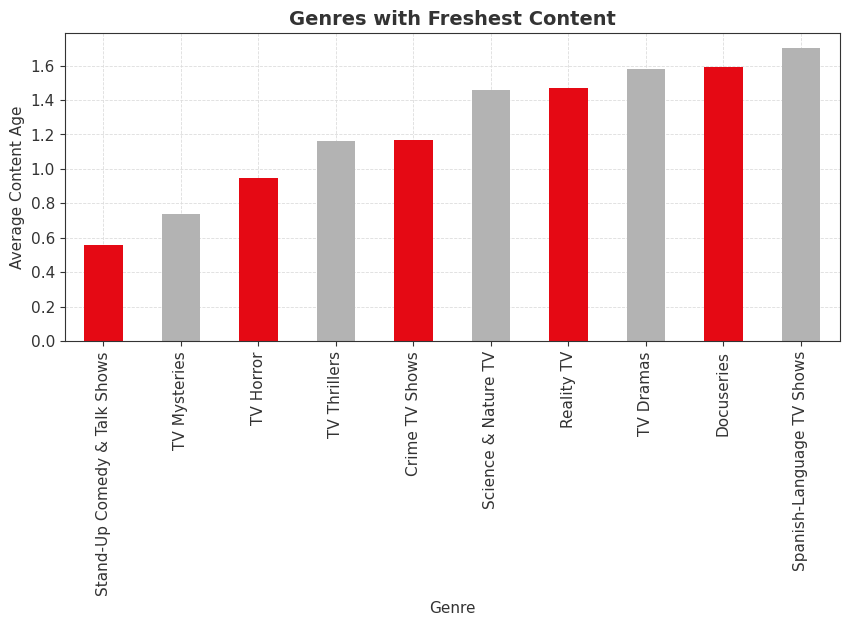

genre
Stand-Up Comedy & Talk Shows    0.555556
TV Mysteries                    0.736842
TV Horror                       0.944444
TV Thrillers                    1.160714
Crime TV Shows                  1.167756
Science & Nature TV             1.459770
Reality TV                      1.467213
TV Dramas                       1.580514
Docuseries                      1.589474
Spanish-Language TV Shows       1.702381
Name: content_age, dtype: float64

In [29]:
genre_age = (
    df_time.assign(genre=df_time['listed_in']
        .str.split(', '))
        .explode('genre')
        .groupby('genre')['content_age'].mean()
        .sort_values()
        .head(10)
)

genre_age.plot(
    kind='bar', 
    color = ['#E50914', '#B3B3B3'] * 5,    
    figsize=(10,4), 
    title='Genres with Freshest Content'
)

plt.xlabel('Genre')
plt.ylabel('Average Content Age')

plt.savefig('../reports/figures/genres_with_freshest_content.png', dpi=300, bbox_inches='tight')

plt.show()

genre_age


**Insight**<br>
Netflix prioritizes freshness for reality, documentary, and high-engagement genres, while classic or serialized categories are supplemented by older catalog content to maintain depth.

**Business Implication**<br>
Timely availability of Reality and Documentary content boosts immediate viewer engagement, while the long tail in classic genres ensures variety, supporting both short-term consumption and long-term retention.

### Netflix Accelerates International Content Growth

**Context**<br>
While the US remains the largest content contributor, additions from India and the United Kingdom have grown rapidly since 2016, alongside a notable “Unknown” segment.

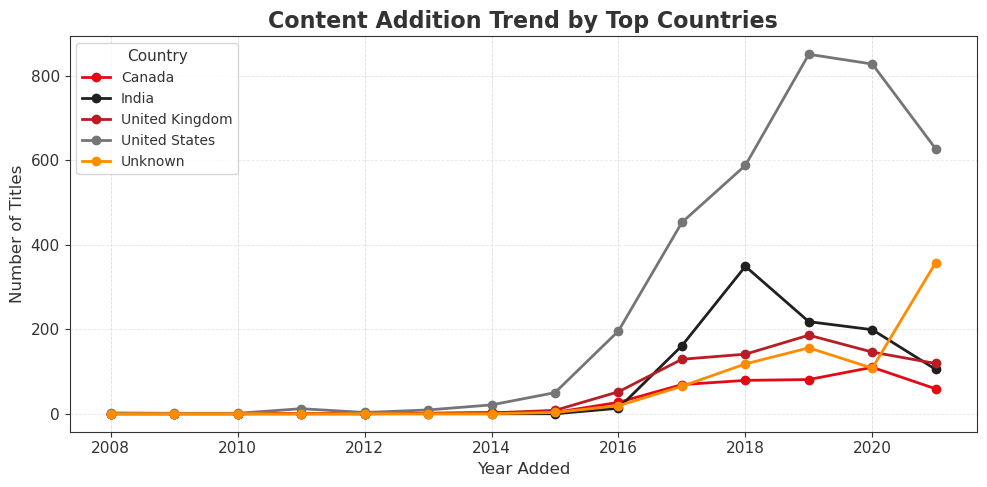

country,Canada,India,United Kingdom,United States,Unknown
year_added,,,,,
2008,0.0,0.0,0.0,2.0,0.0
2009,0.0,0.0,0.0,1.0,0.0
2010,0.0,0.0,0.0,1.0,0.0
2011,0.0,0.0,1.0,12.0,0.0
2012,0.0,0.0,0.0,3.0,0.0
2013,1.0,0.0,1.0,9.0,0.0
2014,3.0,0.0,2.0,21.0,0.0
2015,3.0,0.0,8.0,50.0,3.0
2016,27.0,13.0,52.0,196.0,19.0


In [30]:
country_year = (
    df_time.assign(country=df_time['country']
        .str.split(', '))
        .explode('country')
        .groupby(['year_added', 'country'])
        .size()
        .reset_index(name='count')
)

top_countries = (
    country_year.groupby('country')['count'].sum()
        .sort_values(ascending=False)
        .head(5)
        .index
)

pivot_country = (
    country_year[country_year['country']
        .isin(top_countries)]
        .pivot(index='year_added', columns='country', values='count')
        .fillna(0)
)

colors = ['#E50914', '#221F1F', '#B81D24', '#757575', '#FF8C00']

pivot_country.plot(figsize=(10,5), color=colors, linewidth=2, marker='o')
plt.title('Content Addition Trend by Top Countries', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Country', fontsize=10)
plt.tight_layout()

plt.savefig('../reports/figures/content_addition_trend_by_top_countries.png', dpi=300, bbox_inches='tight')

plt.show()

pivot_country

**Insight**<br>
Netflix is strategically expanding its international library, targeting high-population and English-speaking markets to diversify content and appeal globally.

**Business Implication**<br>
Accelerated content growth from international markets supports global subscriber acquisition, increases engagement across regions, and reinforces Netflix’s position as a leading global streaming platform.

## Conclusion & Strategic Recommendations

### Key Takeaways
- **Content Freshness & Engagement:** Netflix prioritizes recent releases, particularly TV Shows and high-engagement genres like Reality TV and Docuseries, to maximize viewer retention.
- **Movie-Heavy Library for Variety:** Movies dominate most genres, providing broad appeal, while TV Shows and serialized content are leveraged strategically to drive sustained engagement.
- **Global Expansion Focus:** Content growth from India, the UK, and other international markets highlights Netflix’s emphasis on high-population and English-speaking regions.
- **Genre & Rating Strategy:** Mainstream genres and ratings dominate, with niche offerings targeted to specific audiences, balancing scale and demographic reach.
- **Catalog Depth:** A mix of fresh and older titles ensures both immediate relevance and long-tail variety, supporting acquisition and retention strategies.

### Strategic Recommendations
- **Accelerate International & Serialized Content:** Expand high-demand genres in key global markets to drive subscriber growth and engagement.
- **Optimize Catalog Refresh:** Continue adding TV Shows and reality/documentary content close to release while maintaining a curated long-tail of movies for variety.
- **Leverage “Unknown” Metadata:** Investigate content with missing country information to uncover untapped opportunities and enhance regional strategies.
- **Monitor Genre Trends:** Use ongoing analysis of top genres and ratings to align content investments with audience demand and competitive positioning.

### Limitations & Next Steps
- **Data Gaps:** Some titles have missing metadata (e.g., country), which may limit the precision of certain insights.
- **Future Analysis Opportunities:** Incorporate viewer engagement metrics, retention rates, and competitor benchmarking to evaluate content ROI and refine strategy.


---